In [3]:
import zipfile

# Extract the zip file
with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("✅ Extracted! Files available:")
import os
for f in os.listdir('.'):
    print(f)

✅ Extracted! Files available:
.config
googleplaystore_user_reviews.csv
archive (4).zip
license.txt
googleplaystore.csv
sample_data


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from datetime import datetime
import pytz

# Load dataset
df = pd.read_csv('googleplaystore.csv')

# Drop duplicates and nulls
df.drop_duplicates(inplace=True)
df.dropna(subset=['Category', 'Rating', 'Reviews', 'Installs', 'Size', 'Last Updated'], inplace=True)

print("✅ Data loaded! Shape:", df.shape)
df.head()

✅ Data loaded! Shape: (8893, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
# Clean Installs → numeric (handle bad values like 'Free')
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')  # 'Free' becomes NaN
df.dropna(subset=['Installs'], inplace=True)  # drop those bad rows
df['Installs'] = df['Installs'].astype(int)

# Clean Reviews → numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Clean Rating → numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Clean Size → convert to MB
def convert_size(size):
    if 'M' in str(size):
        return float(str(size).replace('M', ''))
    elif 'k' in str(size):
        return float(str(size).replace('k', '')) / 1024
    else:
        return None

df['Size_MB'] = df['Size'].apply(convert_size)

# Clean Last Updated → extract month
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')
df['Update_Month'] = df['Last Updated'].dt.month

print("✅ Cleaning done!")
print(df[['Rating', 'Reviews', 'Installs', 'Size_MB', 'Update_Month']].head())

✅ Cleaning done!
   Rating  Reviews  Installs  Size_MB  Update_Month
0     4.1      159     10000     19.0             1
1     3.9      967    500000     14.0             1
2     4.7    87510   5000000      8.7             8
3     4.5   215644  50000000     25.0             6
4     4.3      967    100000      2.8             6


In [6]:
# Filter: rating >= 4.0, size >= 10MB, last updated in January (month == 1)
filtered_df = df[
    (df['Rating'] >= 4.0) &
    (df['Size_MB'] >= 10) &
    (df['Update_Month'] == 1)
]

# Group by Category
category_group = filtered_df.groupby('Category').agg(
    Total_Installs=('Installs', 'sum'),
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Reviews', 'sum')
).reset_index()

# Top 10 by installs
top10 = category_group.nlargest(10, 'Total_Installs')

print("✅ Top 10 Categories:")
print(top10[['Category', 'Total_Installs', 'Avg_Rating', 'Total_Reviews']])

✅ Top 10 Categories:
            Category  Total_Installs  Avg_Rating  Total_Reviews
7             FAMILY       182494820    4.395455        4544623
19            SPORTS       120511000    4.342857        1982017
10              GAME       115691000    4.313333        2397589
5      ENTERTAINMENT        21000000    4.300000         869111
14   PERSONALIZATION        15060000    4.475000         155996
15       PHOTOGRAPHY        10500000    4.150000         563720
11         LIFESTYLE         5071000    4.380000          42809
4          EDUCATION         2000000    4.400000          57645
20             TOOLS         1010000    4.200000           8010
21  TRAVEL_AND_LOCAL         1001000    4.100000            974


Current IST hour: 15


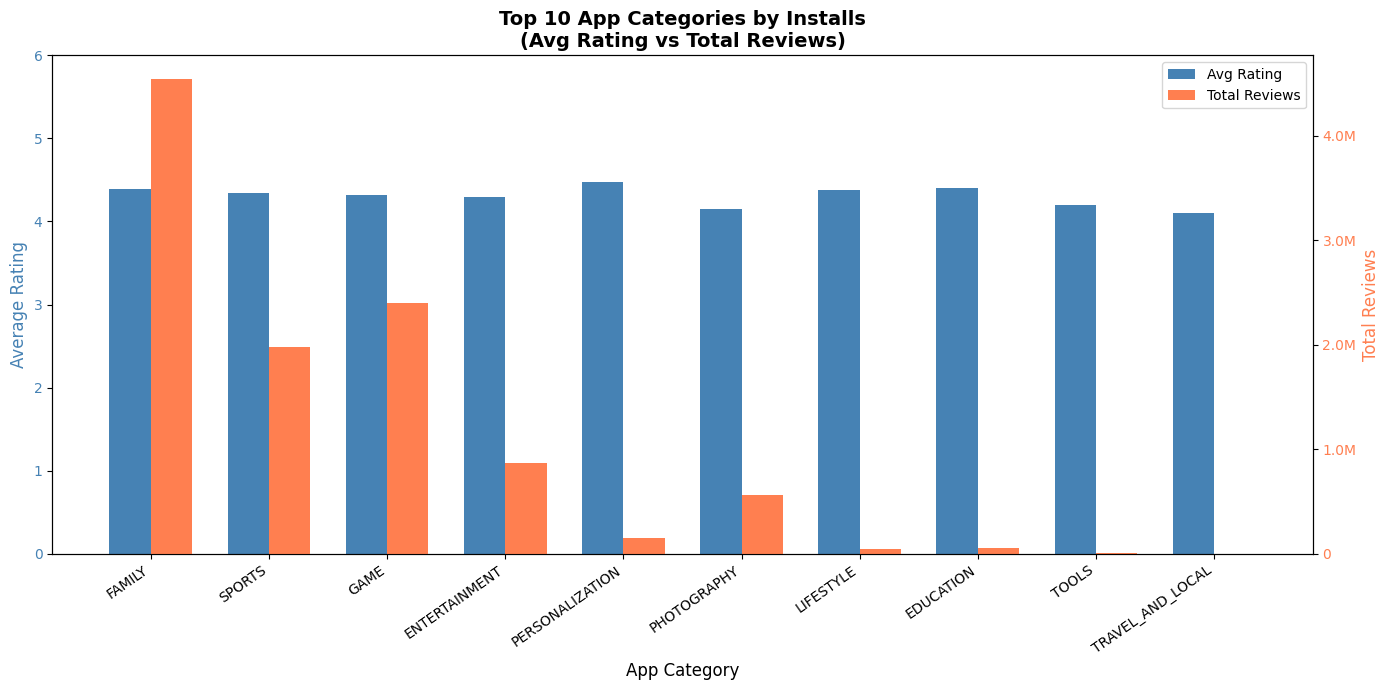

✅ Chart saved!


In [7]:
from datetime import datetime
import pytz

# Check current IST time
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

print(f"Current IST hour: {current_hour}")

if not (15 <= current_hour < 17):
    print("⛔ Chart is only available between 3 PM and 5 PM IST. Please come back then.")

else:
    # Plot the Grouped Bar Chart
    categories = top10['Category']
    x = np.arange(len(categories))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Bar 1: Average Rating (left y-axis)
    bars1 = ax1.bar(x - width/2, top10['Avg_Rating'], width,
                    label='Avg Rating', color='steelblue')
    ax1.set_ylabel('Average Rating', color='steelblue', fontsize=12)
    ax1.set_ylim(0, 6)
    ax1.tick_params(axis='y', labelcolor='steelblue')

    # Bar 2: Total Reviews (right y-axis)
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + width/2, top10['Total_Reviews'], width,
                    label='Total Reviews', color='coral')
    ax2.set_ylabel('Total Reviews', color='coral', fontsize=12)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda val, _: f'{val/1e6:.1f}M' if val >= 1e6 else f'{int(val):,}'
    ))
    ax2.tick_params(axis='y', labelcolor='coral')

    # X-axis labels
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=35, ha='right', fontsize=10)
    ax1.set_xlabel('App Category', fontsize=12)

    # Title & Legends
    plt.title('Top 10 App Categories by Installs\n(Avg Rating vs Total Reviews)',
              fontsize=14, fontweight='bold')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    plt.savefig('top10_categories_chart.png', dpi=150)
    plt.show()
    print("✅ Chart saved!")